In [1]:
import os
from pathlib import Path

def root_dir(marker="EXPLib"):
    cwd = Path.cwd()
    # if cwd already contains the marker
    if (cwd / marker).is_dir():
        return cwd
    # otherwise walk up the parents
    for p in cwd.parents:
        if (p / marker).is_dir():
            return p
    raise FileNotFoundError(f"Root marker '{marker}' not found")

os.chdir(root_dir())
#print(os.getcwd())

In [6]:
from PIL import Image
from transformers import DetrForObjectDetection, AutoImageProcessor
import warnings
from EXPLib.dl_component.Transformers.transformers_MC_utils import force_dropout_in_detr,  enable_dropout, plot_bboxes_with_ci95, mc_dropout_bboxes
import torch
warnings.filterwarnings("ignore", message="Some weights of the model checkpoint.*")
warnings.filterwarnings("ignore", message=".*meta parameter.*")

In [9]:
image_file = './EXPLib/datasets/Camera/toy_model_v1_inference/dev/images/rgb_0000079.png'
im = Image.open(image_file).convert("RGB")

feature_extractor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

model = force_dropout_in_detr(model, p=0.3, backbone_p=0.1)
model.eval()
enable_dropout(model)

mean_boxes, std_boxes, mean_probs = mc_dropout_bboxes(
    model, im, feature_extractor, n_iter=30, conf_thresh=0.3
)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
MC Dropout Runs: 100%|██████████| 30/30 [00:44<00:00,  1.49s/it]


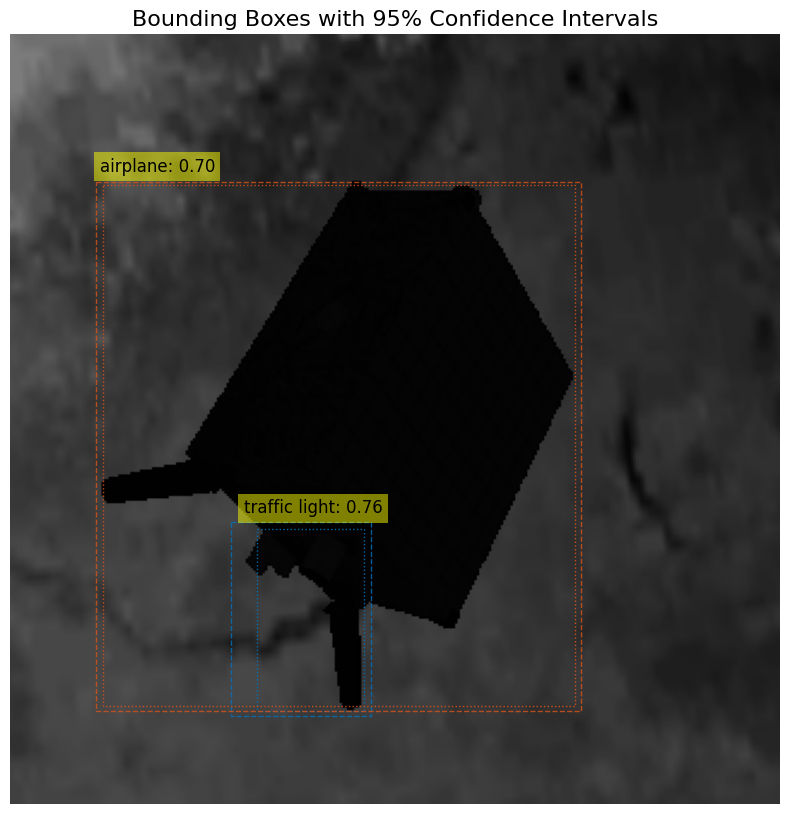

In [10]:
plot_bboxes_with_ci95(im, mean_boxes, std_boxes, mean_probs, model.config.id2label)